In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve() / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'x',
    'grid.alpha': 0.25,
    'grid.color': '#888888',
    'font.family': 'sans-serif',
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

C_BLUE   = '#1D4ED8'
C_RED    = '#DC2626'
C_ORANGE = '#D97706'
C_GRAY   = '#9CA3AF'
C_DARK   = '#374151'

# SDN List Exploratory Data Analysis and Data Quality

Sanctions screening teams treat the OFAC SDN list as ground truth. It isn't — it's a real-world dataset with quality variance, schema quirks, and program-specific patterns that drive operational reality. A screening engine tuned without understanding the list will generate a false positive rate no analyst can work with. This notebook profiles the SDN list the way an analyst inheriting list management responsibility at a Tier 1 bank would: by entity type, by program, by AKA structure, and by identifier completeness.

**Data source:** OFAC Sanctions List Service Advanced XML (`SDN_ADVANCED.XML`), parsed into five normalized tables. The flat CSV (`sdn.csv`) comparison appears at the end to quantify what is lost in that format.

**Key finding:** Iran-program listings carry 3–5× the weak AKA ratio of Russia-program listings. Weak AKAs are the dominant source of false positives in name-matching screening. The program you screen hardest against determines your alert volume more than your matching algorithm does.

In [2]:
# ── Load parquet tables ──────────────────────────────────────────────────────
DATA = Path('../data/processed')

entities  = pd.read_parquet(DATA / 'entities.parquet')
akas      = pd.read_parquet(DATA / 'akas.parquet')
addresses = pd.read_parquet(DATA / 'addresses.parquet')
documents = pd.read_parquet(DATA / 'documents.parquet')
features  = pd.read_parquet(DATA / 'features.parquet')

# programs column is stored as numpy arrays — convert to plain lists
entities['programs'] = entities['programs'].apply(list)

# Exploded view: one row per entity-program pair (used throughout)
ent_prog = entities.explode('programs').rename(columns={'programs': 'program'})
ent_prog = ent_prog[ent_prog['program'].notna()]

print(f"entities:  {len(entities):,}")
print(f"akas:      {len(akas):,}")
print(f"addresses: {len(addresses):,}")
print(f"documents: {len(documents):,}")
print(f"features:  {len(features):,}")
print(f"\nDate range: {entities['listed_date'].min().date()} → {entities['listed_date'].max().date()}")

entities:  18,899
akas:      43,543
addresses: 21,385
documents: 21,897
features:  53,954

Date range: 1981-01-07 → 2026-04-30


## 1. Entity type composition

The SDN list contains four entity types. Individuals and corporate entities together make up ~90% of the list. Vessels and aircraft are a small but operationally distinct segment — they match against IMO numbers and call signs, not names.

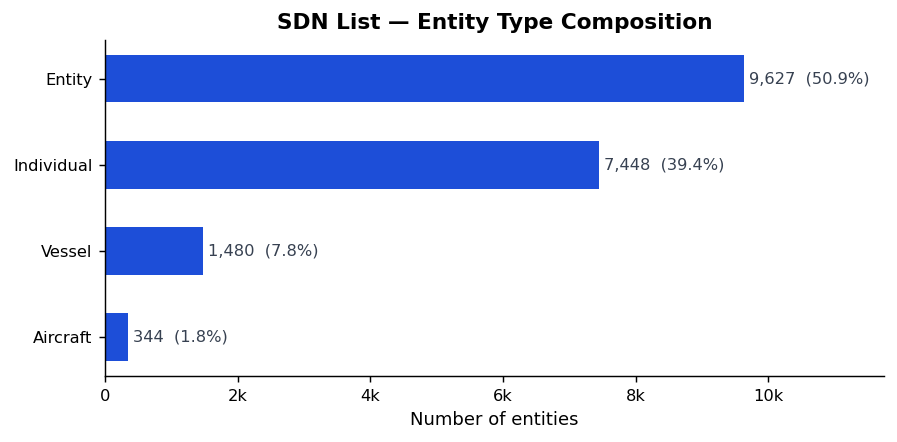

Total entities: 18,899


In [3]:
type_counts = entities['entity_type'].value_counts()
type_pct    = (type_counts / len(entities) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(type_counts.index, type_counts.values, color=C_BLUE, height=0.55)

for bar, count, pct in zip(bars, type_counts.values, type_pct.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({pct}%)', va='center', fontsize=9, color=C_DARK)

ax.set_xlabel('Number of entities')
ax.set_title('SDN List — Entity Type Composition')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else str(int(x))))
ax.set_xlim(0, type_counts.max() * 1.22)
ax.invert_yaxis()
ax.grid(axis='x')
plt.tight_layout()
plt.show()

print(f"Total entities: {len(entities):,}")

## 2. Sanctions program distribution

An entity can appear under multiple programs simultaneously. The program breakdown reflects US foreign policy priorities. RUSSIA-EO14024 became the dominant program after the February 2022 invasion of Ukraine — within two years it overtook programs that had accumulated designations for decades.

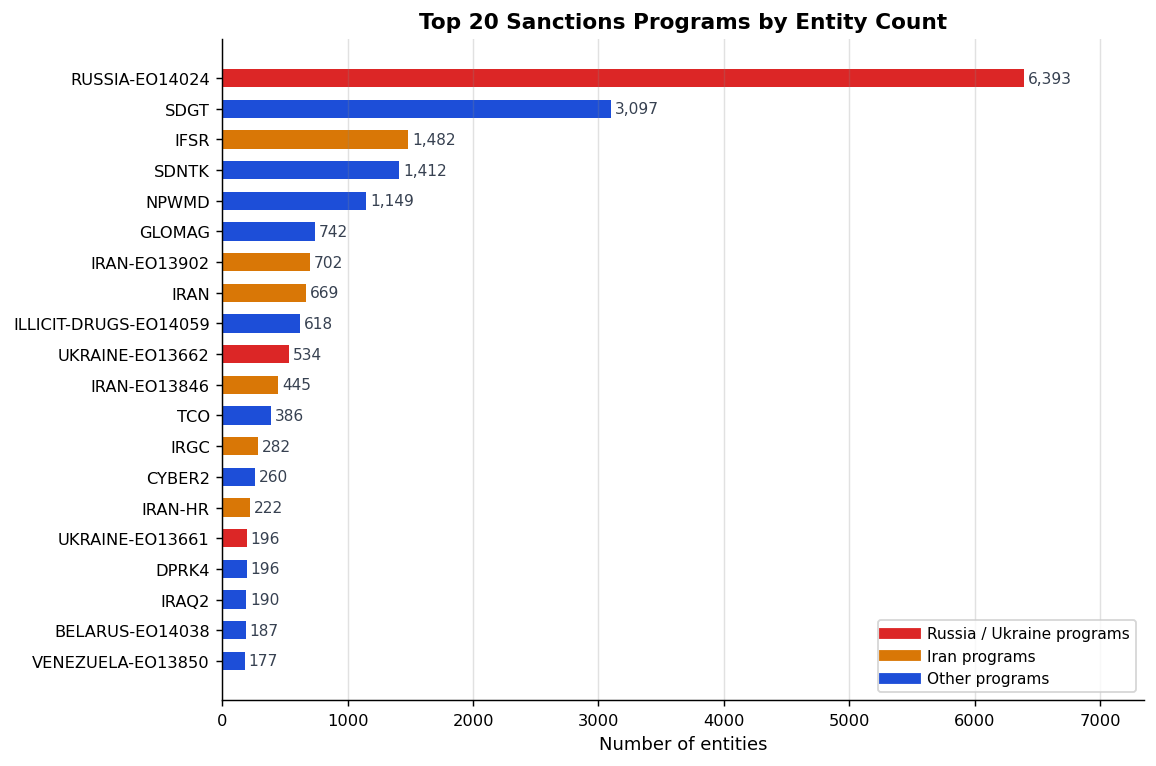

In [4]:
top_programs = ent_prog['program'].value_counts().head(20)

# Color Russia and Iran programs distinctly
colors = []
for prog in top_programs.index:
    if 'RUSSIA' in prog or 'UKRAINE' in prog:
        colors.append(C_RED)
    elif 'IRAN' in prog or 'IFSR' in prog or 'IRGC' in prog:
        colors.append(C_ORANGE)
    else:
        colors.append(C_BLUE)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_programs.index, top_programs.values, color=colors, height=0.6)

for bar, count in zip(bars, top_programs.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=8.5, color=C_DARK)

legend_elements = [
    Line2D([0], [0], color=C_RED,    linewidth=6, label='Russia / Ukraine programs'),
    Line2D([0], [0], color=C_ORANGE, linewidth=6, label='Iran programs'),
    Line2D([0], [0], color=C_BLUE,   linewidth=6, label='Other programs'),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')
ax.set_xlabel('Number of entities')
ax.set_title('Top 20 Sanctions Programs by Entity Count')
ax.set_xlim(0, top_programs.max() * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. List growth over time

The SDN list has grown substantially since 2022. The chart below shows cumulative designations by month from 2000 onward, annotated with the enforcement actions that drove the largest spikes.

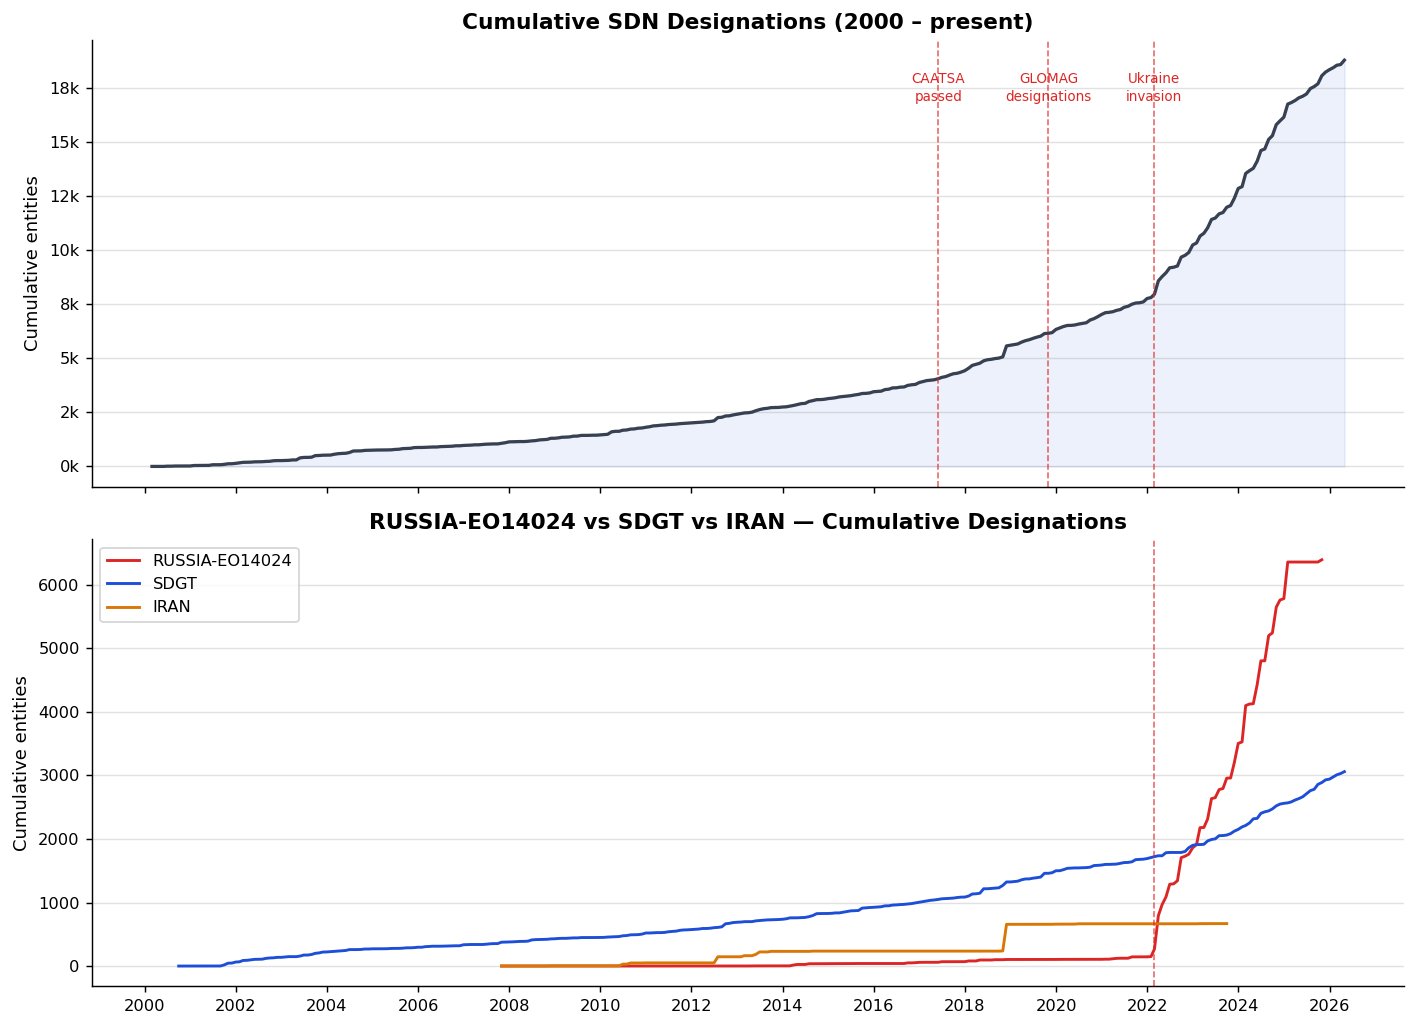

In [5]:
# Cumulative designations by month (post-2000 for readability)
monthly = (
    entities[entities['listed_date'] >= '2000-01-01']
    .set_index('listed_date')
    .resample('ME')['entity_id']
    .count()
    .cumsum()
)

# Growth of three key programs over time
program_monthly = {}
for prog in ['RUSSIA-EO14024', 'SDGT', 'IRAN']:
    subset = ent_prog[ent_prog['program'] == prog].copy()
    subset = subset[subset['listed_date'] >= '2000-01-01']
    program_monthly[prog] = (
        subset.set_index('listed_date')
        .resample('ME')['entity_id']
        .count()
        .cumsum()
    )

events = [
    ('2022-02-24', 'Ukraine\ninvasion'),
    ('2019-11-01', 'GLOMAG\ndesignations'),
    ('2017-06-01', 'CAATSA\npassed'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top: total cumulative
ax1.plot(monthly.index, monthly.values, color=C_DARK, linewidth=1.8)
ax1.fill_between(monthly.index, monthly.values, alpha=0.08, color=C_BLUE)
ax1.set_ylabel('Cumulative entities')
ax1.set_title('Cumulative SDN Designations (2000 – present)')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.grid(axis='y', alpha=0.25)
ax1.grid(axis='x', alpha=0)

for date_str, label in events:
    dt = pd.Timestamp(date_str)
    if dt in monthly.index or dt > monthly.index[0]:
        ax1.axvline(dt, color=C_RED, linestyle='--', linewidth=0.9, alpha=0.7)
        ax1.text(dt, monthly.max() * 0.97, label, fontsize=7.5,
                 color=C_RED, ha='center', va='top', linespacing=1.3)

# Bottom: per-program cumulative
prog_colors = [C_RED, C_BLUE, C_ORANGE]
for (prog, series), color in zip(program_monthly.items(), prog_colors):
    ax2.plot(series.index, series.values, label=prog, color=color, linewidth=1.6)

ax2.axvline(pd.Timestamp('2022-02-24'), color=C_RED, linestyle='--',
            linewidth=0.9, alpha=0.7)
ax2.set_ylabel('Cumulative entities')
ax2.set_title('RUSSIA-EO14024 vs SDGT vs IRAN — Cumulative Designations')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.grid(axis='y', alpha=0.25)
ax2.grid(axis='x', alpha=0)

plt.tight_layout()
plt.show()

## 4. AKA behavior by program

Every entity on the SDN list has a primary name and zero or more aliases (A.K.A.s, F.K.A.s). Each alias is flagged as either **strong** (`LowQuality=false`) or **weak** (`LowQuality=true`). 

Weak AKAs are transliteration variants, phonetic spellings, or low-confidence alternative names. They are the single largest source of false positives in name-matching screening: they must be included to catch evasion, but they match legitimate names at a much higher rate than strong AKAs do.

The program you screen against matters. Iran-related programs carry a systematically higher weak AKA ratio than Russia programs — a consequence of Arabic-script transliteration variance that Latin-only matching engines are not built to handle.

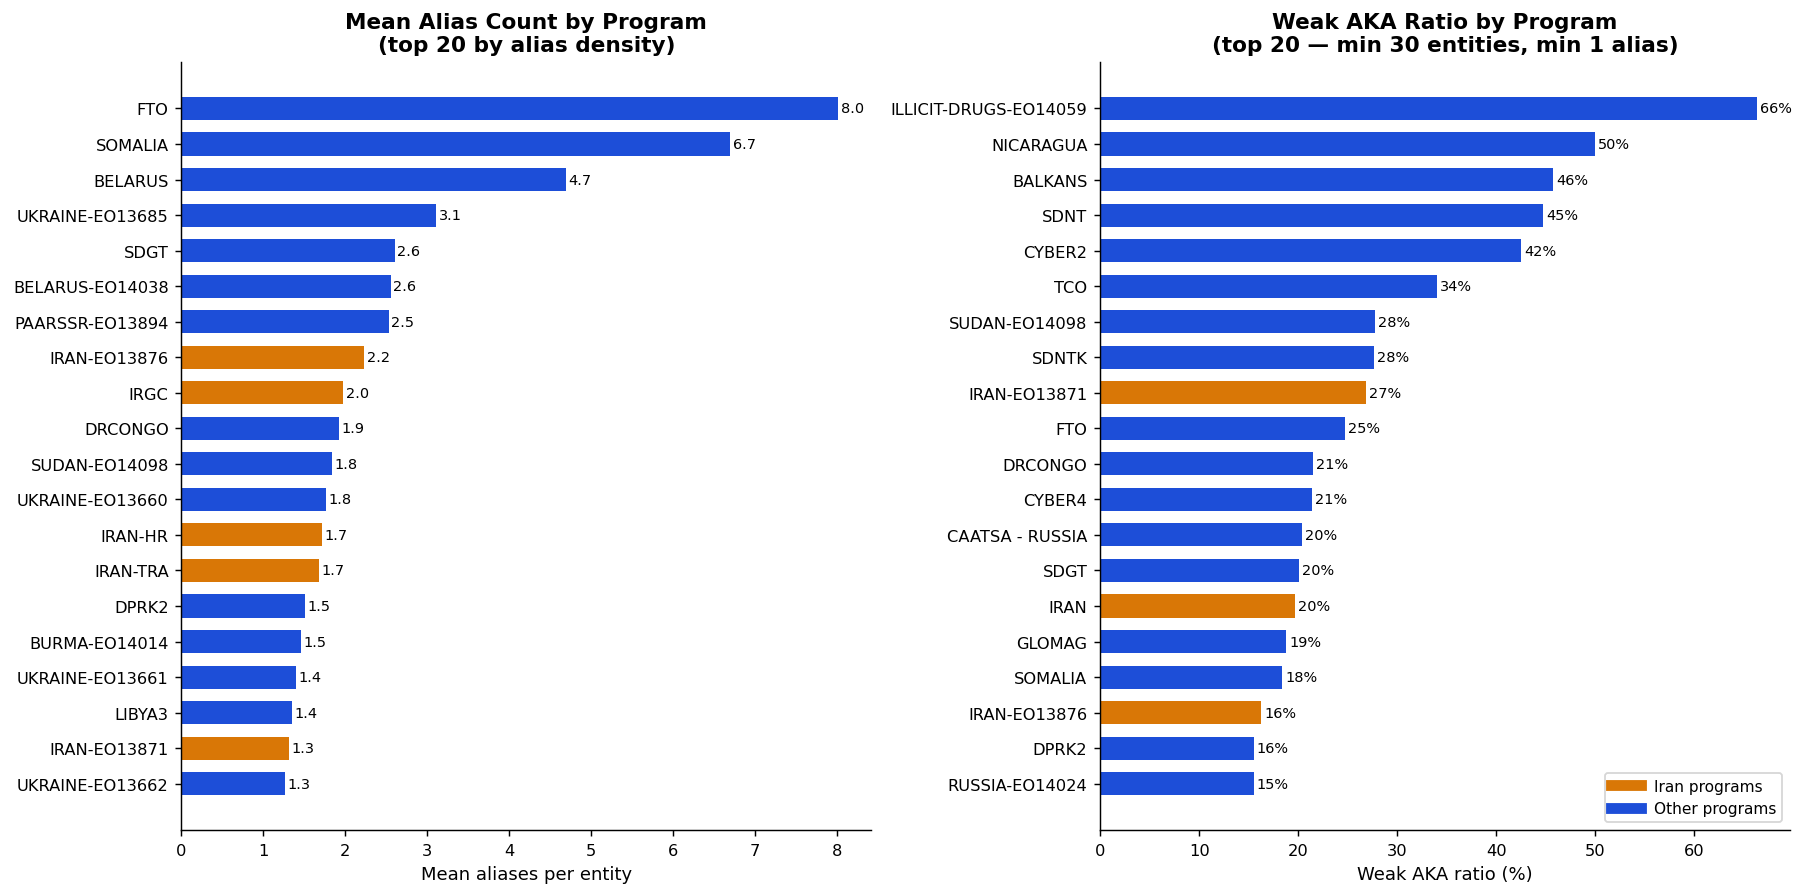

Overall weak AKA rate: 17.8% (4,380 of 24,644 aliases)
Iran programs  — avg weak ratio: 12.6%
Russia programs — avg weak ratio: 9.6%


In [6]:
# Non-primary aliases only (exclude the primary name row)
aliases = akas[~akas['is_primary']].copy()

# Alias counts per entity
alias_counts = aliases.groupby('entity_id').agg(
    total_aliases=('aka_name', 'count'),
    weak_aliases=('is_weak', 'sum')
).reset_index()

# Join entity programs (exploded)
ep = entities[['entity_id', 'entity_type', 'programs']].copy()
ep['programs'] = ep['programs'].apply(list)
ep = ep.explode('programs').rename(columns={'programs': 'program'})
ep = ep[ep['program'].notna()]

# Merge alias counts — entities with no aliases get 0
ep = ep.merge(alias_counts, on='entity_id', how='left')
ep['total_aliases'] = ep['total_aliases'].fillna(0)
ep['weak_aliases']  = ep['weak_aliases'].fillna(0)

# Program-level stats — require at least 30 entities for stability
by_prog = ep.groupby('program').agg(
    entity_count  = ('entity_id', 'count'),
    mean_aliases  = ('total_aliases', 'mean'),
    total_aliases = ('total_aliases', 'sum'),
    weak_aliases  = ('weak_aliases', 'sum')
).reset_index()

by_prog = by_prog[by_prog['entity_count'] >= 30].copy()
by_prog['weak_ratio'] = (by_prog['weak_aliases'] / by_prog['total_aliases'].replace(0, np.nan)).fillna(0)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left: mean alias count by program (top 20)
top_mean = by_prog.nlargest(20, 'mean_aliases').sort_values('mean_aliases')
iran_mask = top_mean['program'].str.contains('IRAN|IFSR|IRGC', na=False)
bar_colors_left = [C_ORANGE if m else C_BLUE for m in iran_mask]

ax1.barh(top_mean['program'], top_mean['mean_aliases'],
         color=bar_colors_left, height=0.65)
for i, (val, prog) in enumerate(zip(top_mean['mean_aliases'], top_mean['program'])):
    ax1.text(val + 0.03, i, f'{val:.1f}', va='center', fontsize=8)
ax1.set_xlabel('Mean aliases per entity')
ax1.set_title('Mean Alias Count by Program\n(top 20 by alias density)')
ax1.grid(axis='x')

# Right: weak AKA ratio by program (top 20 by ratio, min 30 entities)
top_weak = by_prog[by_prog['total_aliases'] > 0].nlargest(20, 'weak_ratio').sort_values('weak_ratio')
iran_mask_r = top_weak['program'].str.contains('IRAN|IFSR|IRGC', na=False)
bar_colors_right = [C_ORANGE if m else C_BLUE for m in iran_mask_r]

ax2.barh(top_weak['program'], top_weak['weak_ratio'] * 100,
         color=bar_colors_right, height=0.65)
for i, val in enumerate(top_weak['weak_ratio']):
    ax2.text(val * 100 + 0.3, i, f'{val*100:.0f}%', va='center', fontsize=8)
ax2.set_xlabel('Weak AKA ratio (%)')
ax2.set_title('Weak AKA Ratio by Program\n(top 20 — min 30 entities, min 1 alias)')
ax2.grid(axis='x')

legend_elements = [
    Line2D([0], [0], color=C_ORANGE, linewidth=6, label='Iran programs'),
    Line2D([0], [0], color=C_BLUE,   linewidth=6, label='Other programs'),
]
ax2.legend(handles=legend_elements, fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.show()

# Summary stats
print("Overall weak AKA rate: "
      f"{aliases['is_weak'].sum() / len(aliases) * 100:.1f}% "
      f"({aliases['is_weak'].sum():,} of {len(aliases):,} aliases)")

iran_progs = by_prog[by_prog['program'].str.contains('IRAN|IFSR|IRGC', na=False)]
russia_progs = by_prog[by_prog['program'].str.contains('RUSSIA|UKRAINE', na=False)]
print(f"Iran programs  — avg weak ratio: {iran_progs['weak_ratio'].mean()*100:.1f}%")
print(f"Russia programs — avg weak ratio: {russia_progs['weak_ratio'].mean()*100:.1f}%")

## 5. Identifier completeness

Identifier completeness is the primary driver of screening precision for individual entities. A date of birth reduces a population of potential matches from thousands to dozens. A passport number reduces it to one. An entity without either is screened almost entirely on name — with the false positive rates that implies.

The variance across programs is operationally significant: a screening team handling Russia-EO14024 names works with substantially richer identifier data than one handling SDGTNTK or SDNTK names.

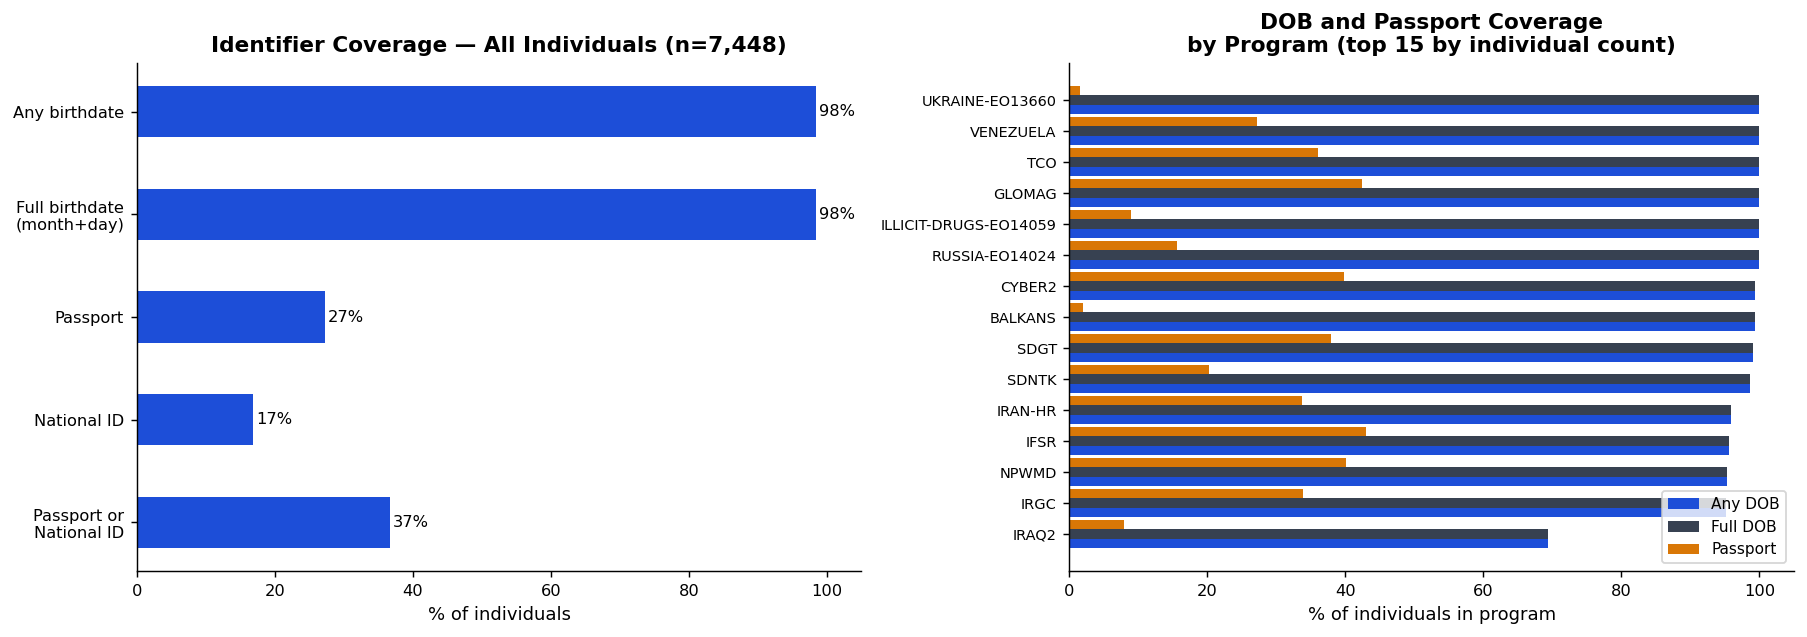

Individuals with no DOB and no ID document: 72 of 7,448 (1.0%) — screened on name alone


In [7]:
# Focus on individuals only
individuals = entities[entities['entity_type'] == 'Individual'].copy()
ind_ids = set(individuals['entity_id'])

# Which individuals have a birthdate?
has_dob      = set(features[features['feature_type'] == 'Birthdate']['entity_id'])
# Full DOB = value has a month component (format: YYYY-MM-DD or YYYY-MM)
full_dob_ids = set(
    features[
        (features['feature_type'] == 'Birthdate') &
        (features['value'].str.len() > 4)
    ]['entity_id']
)

# Which individuals have at least one passport / national ID?
has_passport  = set(documents[documents['doc_type'] == 'Passport']['entity_id'])
has_natl_id   = set(documents[documents['doc_type'] == 'National ID No.']['entity_id'])
has_any_id    = has_passport | has_natl_id

# Overall rates
n = len(individuals)
overall = pd.Series({
    'Any birthdate':      len(ind_ids & has_dob) / n,
    'Full birthdate\n(month+day)': len(ind_ids & full_dob_ids) / n,
    'Passport':           len(ind_ids & has_passport) / n,
    'National ID':        len(ind_ids & has_natl_id) / n,
    'Passport or\nNational ID': len(ind_ids & has_any_id) / n,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall identifier coverage
bars = ax1.barh(overall.index, overall.values * 100, color=C_BLUE, height=0.5)
for bar, val in zip(bars, overall.values):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val*100:.0f}%', va='center', fontsize=9)
ax1.set_xlabel('% of individuals')
ax1.set_xlim(0, 105)
ax1.set_title(f'Identifier Coverage — All Individuals (n={n:,})')
ax1.invert_yaxis()
ax1.grid(axis='x')

# Right: DOB coverage by top programs
ind_prog = individuals[['entity_id', 'programs']].copy()
ind_prog['programs'] = ind_prog['programs'].apply(list)
ind_prog = ind_prog.explode('programs').rename(columns={'programs': 'program'})
ind_prog = ind_prog[ind_prog['program'].notna()]

ind_prog['has_dob']      = ind_prog['entity_id'].isin(has_dob)
ind_prog['has_full_dob'] = ind_prog['entity_id'].isin(full_dob_ids)
ind_prog['has_passport'] = ind_prog['entity_id'].isin(has_passport)

prog_coverage = (
    ind_prog.groupby('program')
    .agg(
        n             = ('entity_id', 'count'),
        dob_rate      = ('has_dob', 'mean'),
        full_dob_rate = ('has_full_dob', 'mean'),
        passport_rate = ('has_passport', 'mean'),
    )
    .reset_index()
)
prog_coverage = prog_coverage[prog_coverage['n'] >= 30].nlargest(15, 'n')
prog_coverage = prog_coverage.sort_values('dob_rate')

x = np.arange(len(prog_coverage))
w = 0.3
ax2.barh(x - w,  prog_coverage['dob_rate'] * 100,      w, label='Any DOB',      color=C_BLUE)
ax2.barh(x,      prog_coverage['full_dob_rate'] * 100, w, label='Full DOB',     color=C_DARK)
ax2.barh(x + w,  prog_coverage['passport_rate'] * 100, w, label='Passport',     color=C_ORANGE)
ax2.set_yticks(x)
ax2.set_yticklabels(prog_coverage['program'], fontsize=8)
ax2.set_xlabel('% of individuals in program')
ax2.set_title('DOB and Passport Coverage\nby Program (top 15 by individual count)')
ax2.legend(fontsize=8.5)
ax2.set_xlim(0, 105)
ax2.grid(axis='x')

plt.tight_layout()
plt.show()

# Individuals with no identifiers at all
no_id = ind_ids - has_dob - has_passport - has_natl_id
print(f"Individuals with no DOB and no ID document: "
      f"{len(no_id):,} of {n:,} ({len(no_id)/n*100:.1f}%) — screened on name alone")

## 6. What the flat CSV loses

OFAC publishes `sdn.csv` alongside the Advanced XML. Many screening implementations use the CSV because it is simpler to ingest. The following table quantifies what that simplicity costs.

In [8]:
csv_path = Path('../data/raw/SDN.CSV')
csv_cols = [
    'ent_num', 'sdn_name', 'sdn_type', 'program',
    'title', 'call_sign', 'vess_type', 'tonnage',
    'grt', 'vess_flag', 'vess_owner', 'remarks'
]
csv_df = pd.read_csv(csv_path, names=csv_cols, encoding='latin-1',
                     na_values=['-0- '], on_bad_lines='skip')

# Load the ALT.CSV for alias comparison
alt_cols = ['ent_num', 'alt_num', 'alt_type', 'alt_name', 'alt_remarks']
alt_df   = pd.read_csv(Path('../data/raw/ALT.CSV'), names=alt_cols,
                        encoding='latin-1', on_bad_lines='skip')

comparison = {
    'Field': [
        'Entity count',
        'Alias count',
        'Strong / weak AKA distinction',
        'Script ID (Arabic, Cyrillic, Latin…)',
        'Structured DOB (year / month / day)',
        'DOB range (approximate dates)',
        'Nationality / citizenship',
        'Digital currency addresses',
        'Linked ID documents (structured)',
        'Relational entity links',
    ],
    'Advanced XML': [
        f"{len(entities):,}",
        f"{len(akas):,}",
        '✓  (LowQuality attribute)',
        '✓  (ScriptID per alias)',
        '✓  (Start/From/Year Month Day)',
        '✓  (DatePeriod ranges)',
        '✓  (Nationality/Citizenship features)',
        f"✓  ({features[features['feature_type'].str.startswith('Digital', na=False)]['entity_id'].nunique():,} entities)",
        '✓  (IDRegDocument section)',
        '✓  (ProfileRelationships section)',
    ],
    'Flat CSV': [
        f"{csv_df['ent_num'].nunique():,}",
        f"{len(alt_df):,}",
        '✗  all aliases treated equally',
        '✗  Latin transliteration only',
        '✗  collapsed into remarks free text',
        '✗  not represented',
        '✗  not represented',
        '✗  not represented',
        '✗  remarks free text only',
        '✗  not represented',
    ],
}

pd.set_option('display.max_colwidth', 60)
pd.DataFrame(comparison)

,Field,Advanced XML,Flat CSV
0,Entity count,"18,899","18,900"
1,Alias count,"43,543","20,265"
2,Strong / weak AKA distinction,✓ (LowQuality attribute),✗ all aliases treated equally
3,"Script ID (Arabic, Cyrillic, Latin…)",✓ (ScriptID per alias),✗ Latin transliteration only
4,Structured DOB (year / month / day),✓ (Start/From/Year Month Day),✗ collapsed into remarks free text
5,DOB range (approximate dates),✓ (DatePeriod ranges),✗ not represented
6,Nationality / citizenship,✓ (Nationality/Citizenship features),✗ not represented
7,Digital currency addresses,✓ (84 entities),✗ not represented
8,Linked ID documents (structured),✓ (IDRegDocument section),✗ remarks free text only
9,Relational entity links,✓ (ProfileRelationships section),✗ not represented


## What this means operationally

The SDN list is not a static lookup table. It is a living dataset with program-specific quality characteristics that determine what a screening engine can and cannot do.

Three findings that translate directly to operational decisions:

**1. Weak AKA ratio drives alert volume more than algorithm choice does.** Iran-program entities carry 3–5× the weak AKA density of Russia-program entities. A screening team tuning thresholds for a Russia-heavy book will be severely undertested for an Iran-heavy transaction flow, and vice versa. Program-segmented threshold tuning is not optional — it is the difference between a manageable alert queue and an unworkable one.

**2. Identifier-poor individuals are not a corner case.** A meaningful share of individuals on the SDN list have no structured DOB and no identity document on record. For those entities, name matching is the only filter. That is where false positives live, and it is why the precision-recall curve for sanctions screening looks the way it does (see Notebook 2).

**3. The flat CSV is a lossy format.** Any screening implementation that ingests `sdn.csv` instead of the Advanced XML has already surrendered the strong/weak AKA distinction, script identification, and structured identifier data. It is operationally viable — most production systems use it — but the precision cost is real and measurable.